# Streaming Diarization Results Analysis

This notebook analyzes the evaluation results from streaming diarization experiments on the CallHome English dataset.

**Experiment:** `callhome_eng`  
**Systems Compared:**
- `diart_default` - DIART with default parameters
- `diart_custom` - DIART with custom parameters
- `streaming_sortformer` - Streaming SortFormer system

## Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Import analysis modules
import data_loader
import visualizations
import stats_report

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Display options
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 4)

## Load Evaluation Results

In [2]:
# Load the metrics CSV file
csv_path = Path("../results/callhome_eng/metrics.csv")
df = data_loader.load_metrics(csv_path, verbose=True)

✓ Loaded 420 results from ..\results\callhome_eng\metrics.csv
  Number of recordings: 140
  Systems evaluated: diart_default, diart_custom, streaming_sortformer
  Metrics captured: 26 columns
  Created derived metrics (RTF)


## Data Overview

In [3]:
# Display sample of data
display(df.head())

# Print dataset summary
stats_report.print_dataset_summary(df)

,recording_id,system,DER,false_alarm,missed_detection,confusion,JER,latency_mean_ms,latency_std_ms,peak_latency_ms,peak_latency_chunk_idx,num_chunks,step_size_ms,duration,peak_gpu_mem_mb,peak_gpu_util_pct,avg_gpu_util_pct,peak_ram_mb,avg_cpu_percent,wall_time_s,total_speech_time,gt_num_speakers,gt_overlap_rate,avg_segment_confidence,min_segment_confidence,rtf
0,callhome_eng_0000,diart_default,0.1707,11.368,20.517,12.508,0.2458,67.7814,27.6998,241.4838,0,598,500.0,303.12,1020.5128,39,34.3662,4311.0482,396.7501,41.7396,260.050,2,0.0317,NaN,NaN,0.1377
1,callhome_eng_0001,diart_default,0.3934,22.298,99.571,128.723,0.4852,68.2061,27.4066,166.7002,1122,1196,500.0,602.21,636.3740,39,33.9859,4428.0750,395.5552,84.4547,637.067,2,0.1460,NaN,NaN,0.1402
2,callhome_eng_0002,diart_default,0.4511,14.458,18.011,66.459,0.6323,66.6686,27.2757,104.0796,395,601,500.0,304.68,636.3740,39,35.2113,4352.3195,397.8324,41.4260,219.281,2,0.0093,NaN,NaN,0.1360
3,callhome_eng_0003,diart_default,0.4839,9.204,39.885,45.870,0.5901,67.4929,27.1374,111.1996,438,593,500.0,300.56,636.3740,43,34.1268,4351.8075,396.7583,41.3087,196.230,2,0.0336,NaN,NaN,0.1374
4,callhome_eng_0004,diart_default,0.4796,15.634,52.292,209.684,0.6330,66.4724,27.5307,166.2528,457,1195,500.0,602.00,636.3740,44,33.9296,4390.3468,398.7268,81.6103,578.855,2,0.0681,NaN,NaN,0.1356



DATASET SUMMARY
Total recordings: 140
Systems evaluated: diart_default, diart_custom, streaming_sortformer
Total rows: 420
Columns: 26


## Ground Truth Dataset Characteristics

Analysis of the CallHome dataset properties used for evaluation.

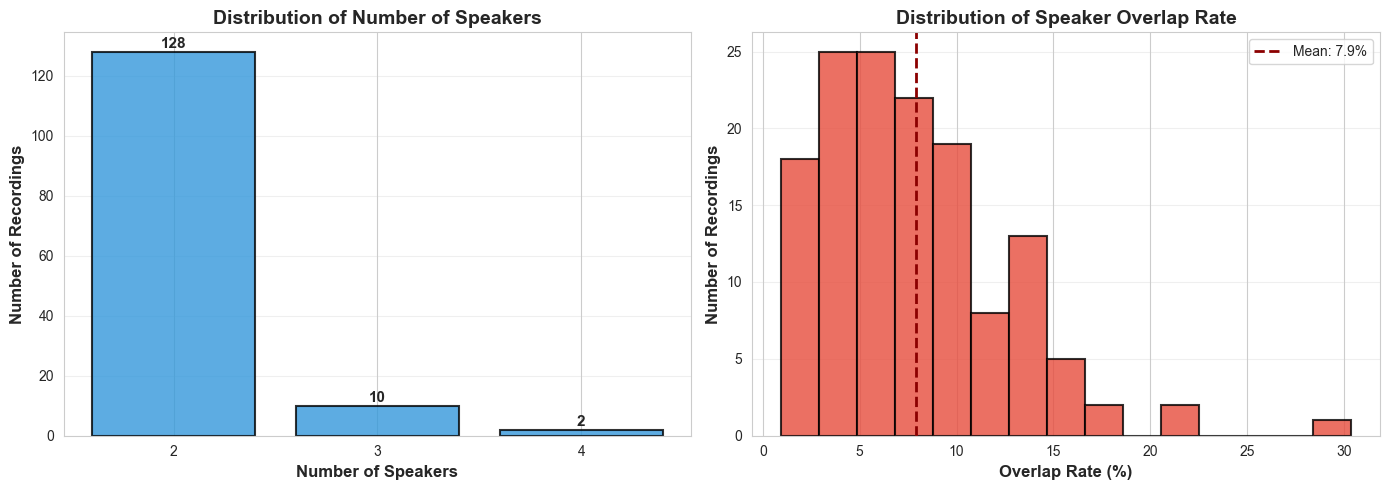

In [4]:
# Prepare ground truth data
gt_data = data_loader.prepare_ground_truth_data(df)

# Plot ground truth characteristics
visualizations.plot_ground_truth_characteristics(gt_data)

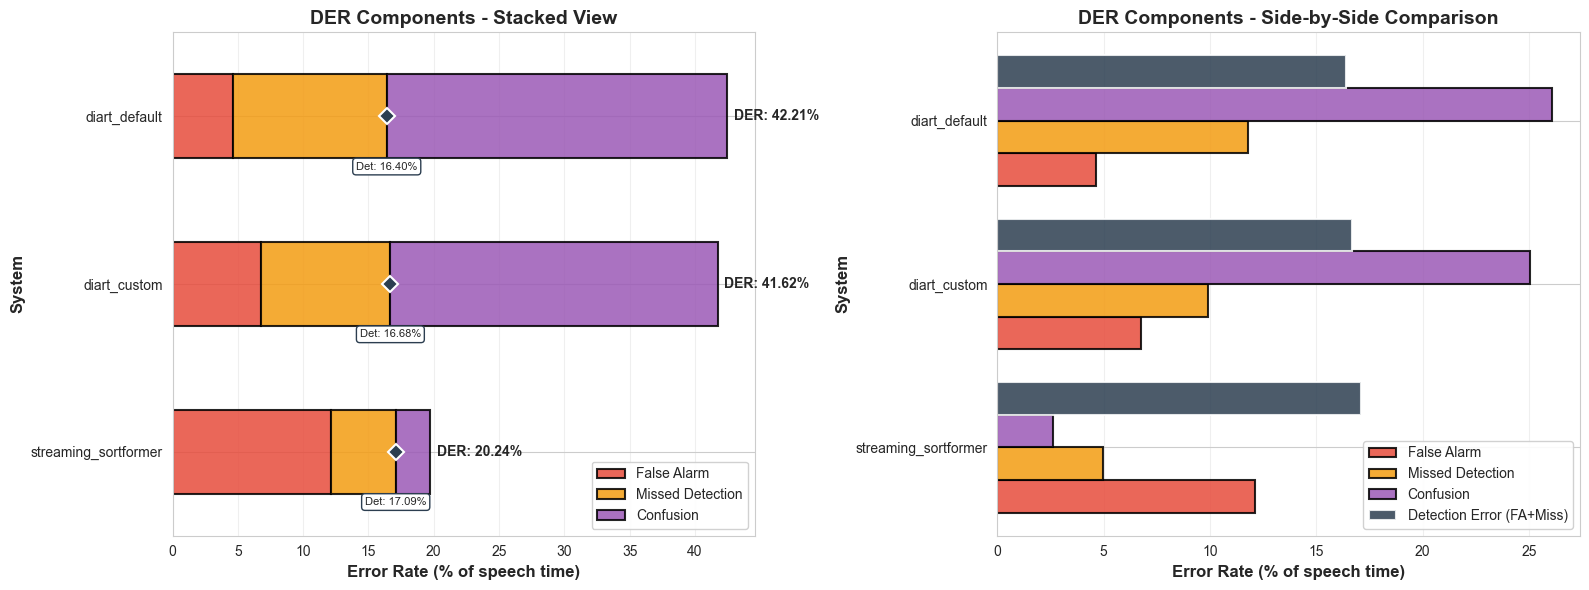


DER COMPONENT ANALYSIS

streaming_sortformer:
  Total DER:          20.24%
  ├─ False Alarm:     12.10% ( 59.8% of DER)
  ├─ Missed Detect:    4.99% ( 24.6% of DER)
  └─ Confusion:        2.63% ( 13.0% of DER)

diart_custom:
  Total DER:          41.62%
  ├─ False Alarm:      6.76% ( 16.2% of DER)
  ├─ Missed Detect:    9.92% ( 23.8% of DER)
  └─ Confusion:       25.05% ( 60.2% of DER)

diart_default:
  Total DER:          42.21%
  ├─ False Alarm:      4.62% ( 11.0% of DER)
  ├─ Missed Detect:   11.78% ( 27.9% of DER)
  └─ Confusion:       26.09% ( 61.8% of DER)


In [5]:
# Plot DER components analysis
visualizations.plot_der_components(df)

# Print detailed component analysis
stats_report.print_der_component_analysis(df)

## DER per Recording Analysis

Heatmap showing DER for each recording across all systems.

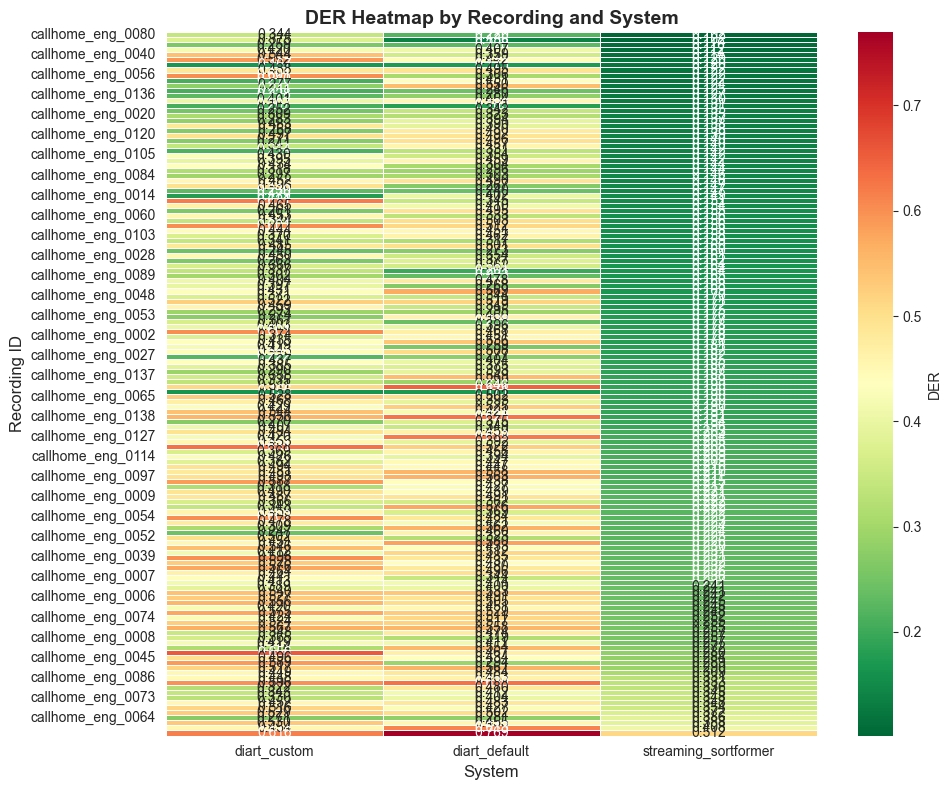


BEST PERFORMING SYSTEM PER RECORDING
streaming_sortformer    135
diart_custom              5
Name: count, dtype: int64


In [6]:
# Plot DER heatmap sorted by streaming_sortformer performance
der_pivot = visualizations.plot_der_heatmap(df, sort_by_system='streaming_sortformer')

# Show which system wins for each recording
stats_report.print_best_system_per_recording(der_pivot)

## DER vs. Overlap Rate

Analysis of how speaker overlap affects diarization accuracy.

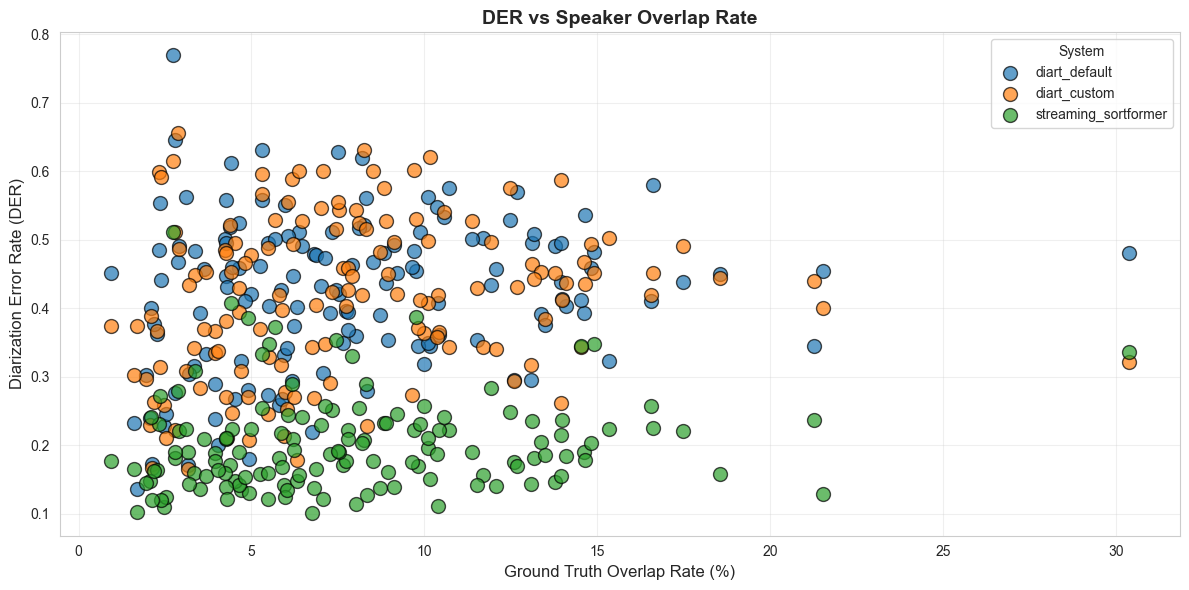


Correlation: DER vs overlap rate
------------------------------------------------------------
diart_default            : +0.180
diart_custom             : +0.160
streaming_sortformer     : +0.126


In [7]:
# Plot DER vs overlap rate scatter
visualizations.plot_der_vs_overlap(df)

# Print correlation analysis
stats_report.print_correlation_analysis(df, metric='DER', variable='gt_overlap_rate', 
                           variable_display_name='overlap rate')

## Processing Efficiency

Real-Time Factor (RTF) and processing time analysis.


REAL-TIME FACTOR (RTF) STATISTICS
(RTF < 1.0 means faster than real-time)

                        mean     std     min     max
system                                              
diart_custom          0.1461  0.0040  0.1384  0.1538
diart_default         0.1400  0.0028  0.1353  0.1569
streaming_sortformer  0.0512  0.0003  0.0508  0.0535

Processing Speed (relative to real-time):
------------------------------------------------------------
diart_default            : 7.14x real-time speed
diart_custom             : 6.85x real-time speed
streaming_sortformer     : 19.53x real-time speed


c:\Users\mbielak\Projects\streaming-diarization-eval\analysis\visualizations.py:203: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='system', y='rtf', ax=axes[0], palette='Set2')


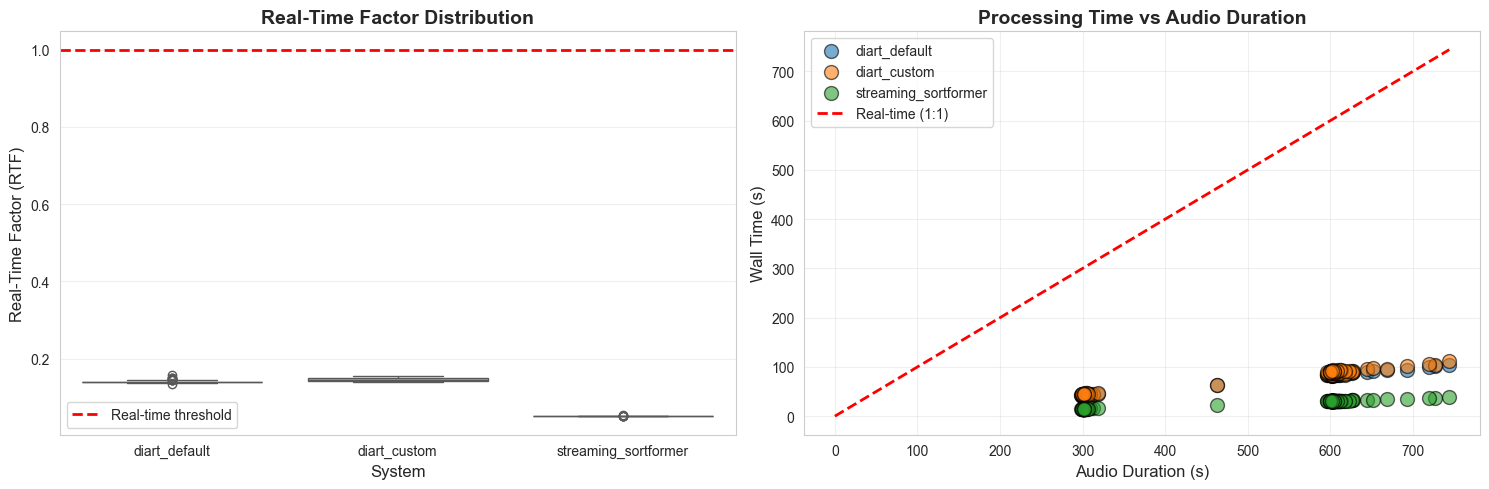

In [8]:
# Print RTF statistics
stats_report.print_rtf_statistics(df)

# Plot processing efficiency
visualizations.plot_processing_efficiency(df)

## Resource Usage

GPU, RAM, and CPU utilization statistics.


RESOURCE USAGE STATISTICS
                      peak_gpu_mem_mb  avg_gpu_util_pct  peak_ram_mb  \
system                                                                 
diart_custom                 636.3740           35.9701    4597.4067   
diart_default                639.1179           33.7266    4443.6687   
streaming_sortformer         606.1643           92.3695    4820.1421   

                      avg_cpu_percent  
system                                 
diart_custom                 397.0544  
diart_default                396.9322  
streaming_sortformer          99.9814  


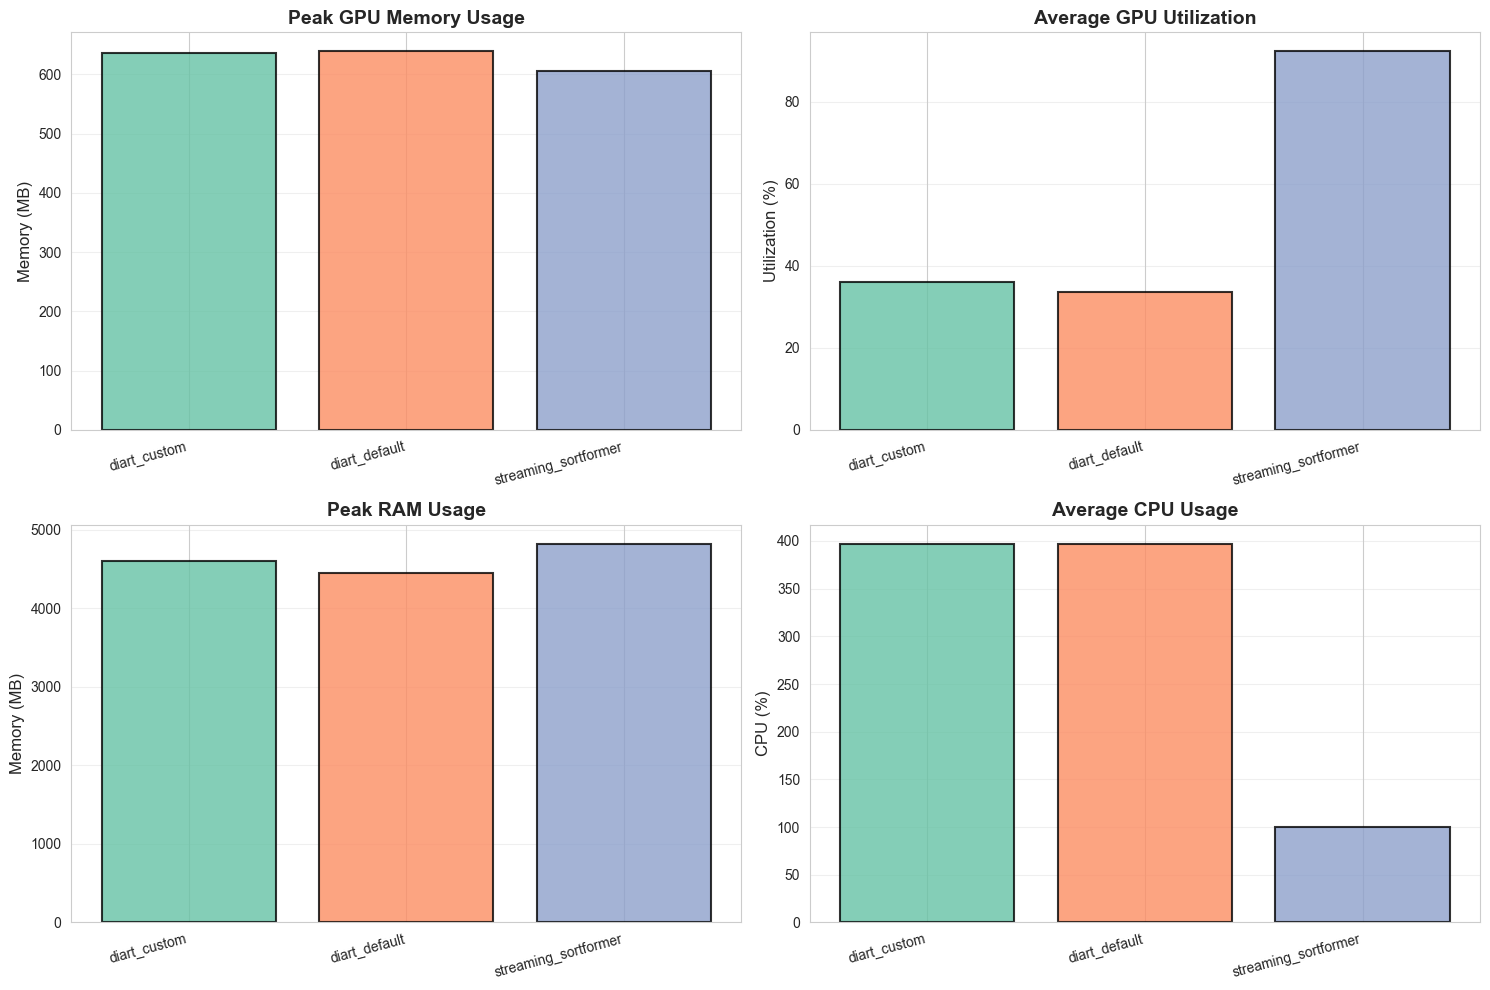

In [9]:
# Print resource usage statistics
stats_report.print_resource_statistics(df)

# Plot resource usage
visualizations.plot_resource_usage(df)

## Latency Analysis

Processing latency comparison across systems.


LATENCY STATISTICS (milliseconds)
                      latency_mean_ms  latency_std_ms  peak_latency_ms
system                                                                
diart_custom                  71.9325         26.4179         190.1992
diart_default                 68.5058         28.0833         178.9771
streaming_sortformer          51.1566          8.2024          72.4283


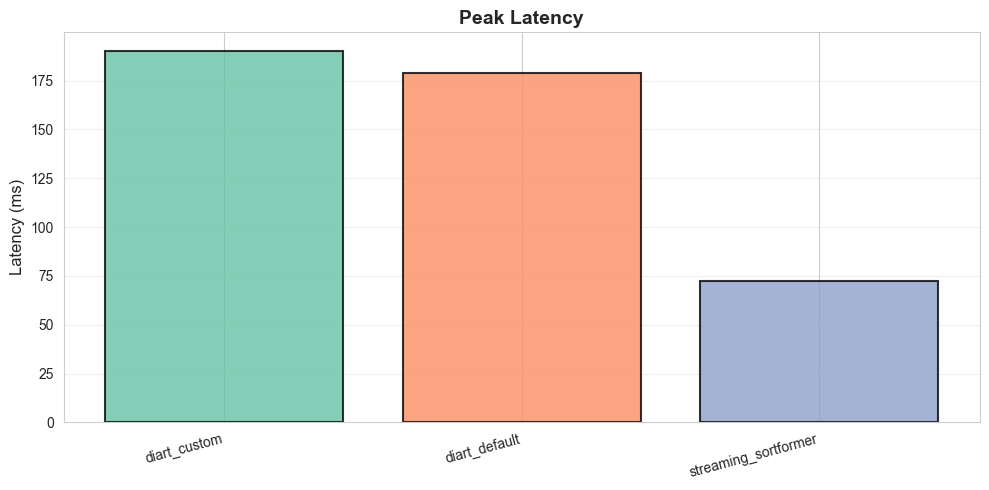

In [10]:
# Print latency statistics
stats_report.print_latency_statistics(df)

# Plot latency analysis
visualizations.plot_latency_analysis(df)